## Definition
1. um, fs, keV
2. normal is pointing inwards the reflection surface
3. The coordinate convention of this simulation and its relation to XPP coordinate is 
    (axis 0, axis 1, axis 2) = (vertical, horizontal, propagation) = (xpp y, xpp x, xpp z)
    i.e., The name in this code is x,y,z, using one convension. In the text, use the XPP convention 
   
## Convention for FFT

np.fft(field) = spectrum

np.ifft(spectrum) = field

# Step 1: Ray Tracing Calculation

In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from matplotlib import colormaps

sys.path.append("../../../../XRaySimulation")

from XRaySimulation import Pulse, DeviceSimu, util, Crystal
from rayTracingCalculation import prepare_beam_optics, get_miniSD_and_TG_trajectory, \
    get_coefficient_for_two_configurations, get_trajectory_dependence_on_various_parameters

import physicalModelVisualization
import eFieldProcessing
import parser
import Controller
import time
plt.rcParams.update({'font.size': 14})

CudaSupportError: Error at driver init: 

CUDA driver library cannot be found.
If you are sure that a CUDA driver is installed,
try setting environment variable NUMBA_CUDA_DRIVER
with the file path of the CUDA driver shared library.
:

In [2]:
# Create the experiment setup
exp = Controller.XppController_TG()

/global/cfs/cdirs/lcls/xpcs/md/haoyuan/autoAlignment/XRaySimulation/Projects/autoAlign/notebooks/../../../../XRaySimulation/XRaySimulation/Crystal.py:233: RuntimeWarning: invalid value encountered in divide
  direction1 /= np.linalg.norm(direction1)


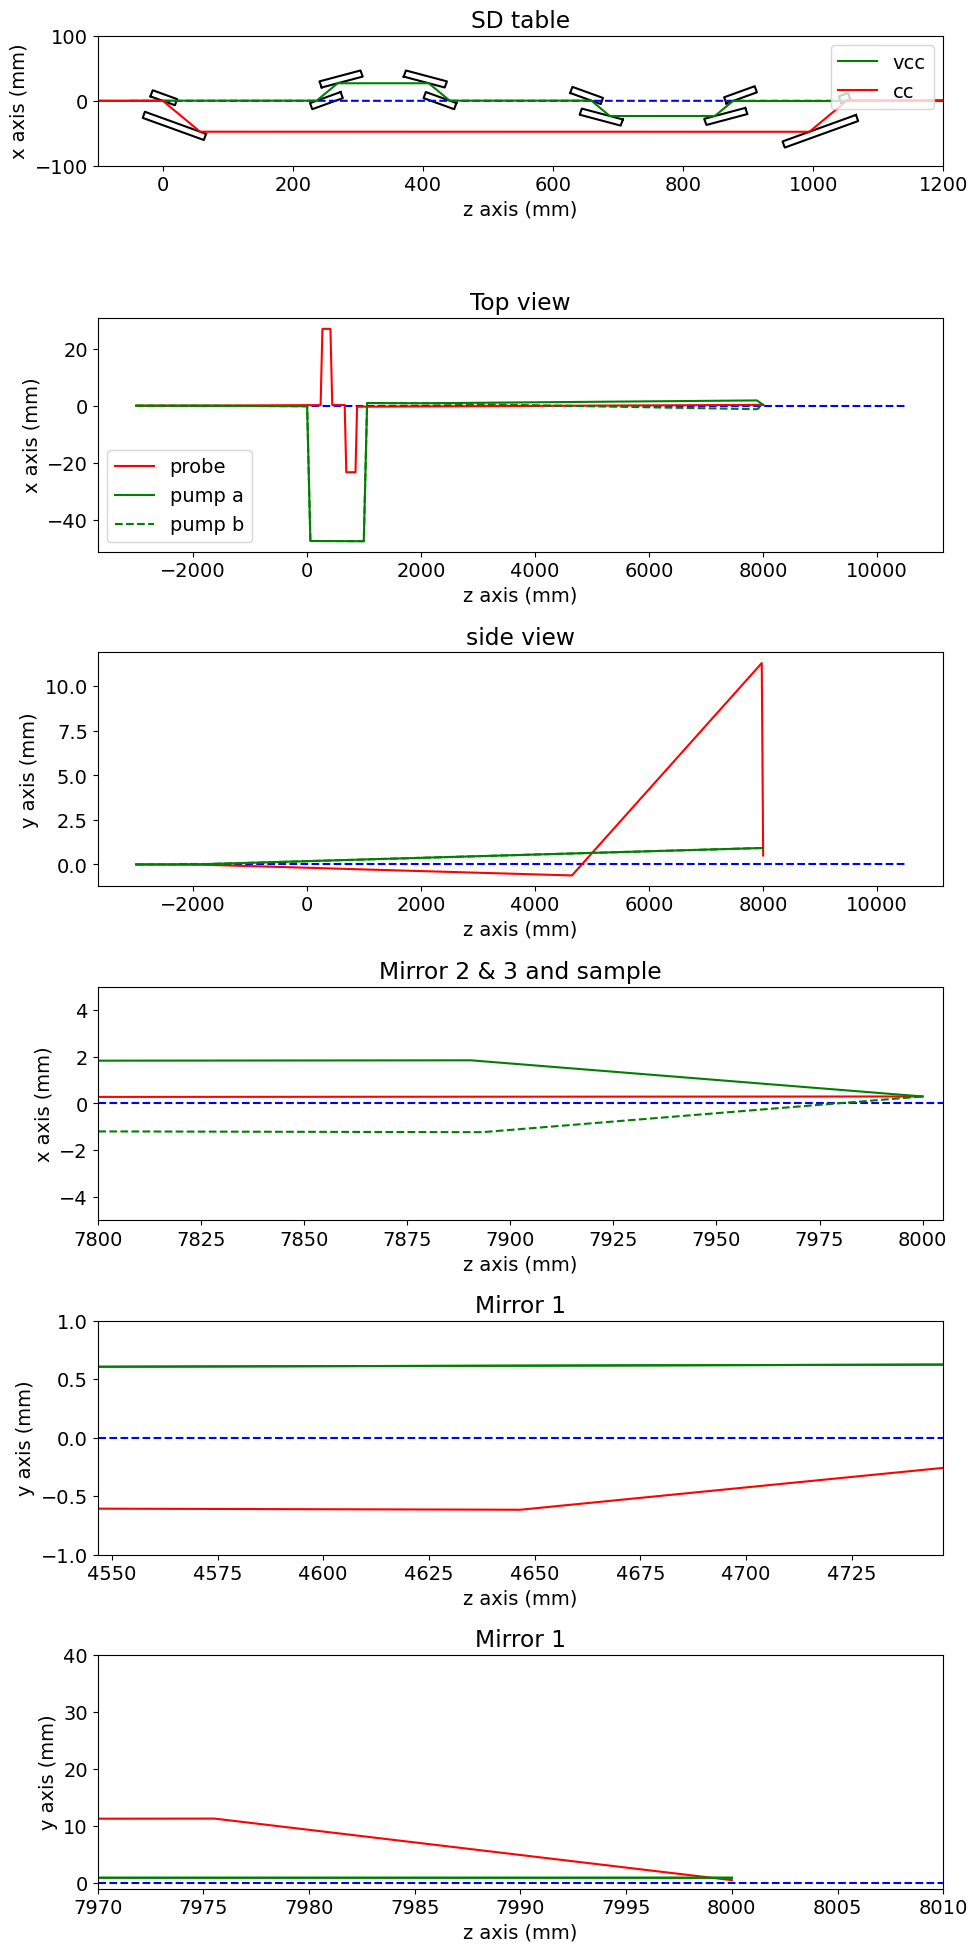

In [3]:
physicalModelVisualization.showSDandTGtrajectory(simulation_summary=exp.expSimu)

# Step 2: Collect the measurment from a SASE pulses

In [4]:
# Tweak the setup a little bit
parser.parser(controller=exp, motor_name='t2x', target=0)
parser.parser(controller=exp, motor_name='t3x', target=0)

0

In [5]:
Ec = 9.5  # keV
klen0 = util.kev_to_wavevec_length(Ec)  # The center wave-vector length

nx = 32  # For y axis in XPP frame
ny = 32  # For x axis in XPP frame
nz = 1024  # For z axis in XPP frame

dx = 16
dy = 16
dz = 50 * util.c / nz  # The total pulse duration is 50 fs in this simulation

# Get kin grid
(xCoor, yCoor, zCoor, tCoor,
 kxCoor, kyCoor, kzCoor,
 ExCoor, EyCoor, EzCoor) = util.get_coordinate(nx=nx, ny=ny, nz=nz,
                                               dx=dx, dy=dy, dz=dz,
                                               k0=klen0)
coordinate_dict = {'xCoor': xCoor, 'yCoor': yCoor, 'zCoor': zCoor, 'tCoor': tCoor,
                   'kxCoor': kxCoor, 'kyCoor': kyCoor, 'kzCoor': kzCoor,
                   'ExCoor': ExCoor, 'EyCoor': EyCoor, 'EzCoor': EzCoor, }

kinGrid = np.zeros((nx, ny, nz, 3))
kinGrid[:, :, :, 0] = kxCoor[:, np.newaxis, np.newaxis]
kinGrid[:, :, :, 1] = kyCoor[np.newaxis, :, np.newaxis]
kinGrid[:, :, :, 2] = kzCoor[np.newaxis, np.newaxis, :]


result_summary = []

tic = time.time()
for idx in range(1):
    # Generate a sase field
    sase_field = Pulse.getGaussianModeSum(nx=nx, ny=ny, nz=nz, dx=dx, dy=dy, dz=dz,
                                      nGaussian=500,
                                      modeSizeX=100,
                                      modeSizeY=100,
                                      modeSizeZ=0.15 * util.c, 
                                      modeCenterSpreadX=0.1,
                                      modeCenterSpreadY=0.1,
                                      modeCenterSpreadZ=20 * util.c,  
                                      k0=klen0,
                                      randomSeed=41)
    # Get the measruement 
    result_summary.append(exp.get_measurement(sase_field=sase_field,
                                              kGrid=kinGrid,
                                              coor_dict=coordinate_dict))

toc = time.time()
print("It takes {:.2f} seconds to process {} pulses".format(toc - tic, len(result_summary)))

/global/common/software/nersc/pe/conda-envs/24.1.0/python-3.11/nersc-python/lib/python3.11/site-packages/numba/cuda/cudadrv/devicearray.py:886: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


[464.61740542 761.19508723]
[-464.76101358 -161.94463386]
It takes 7.38 seconds to process 1 pulses


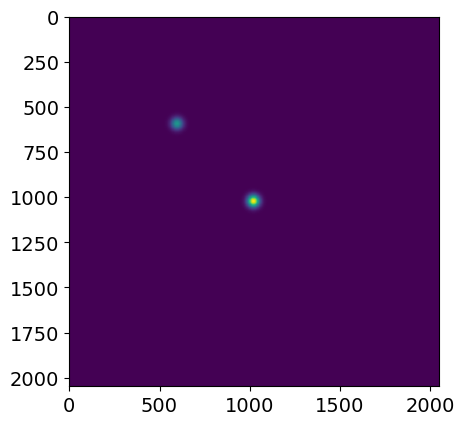

In [6]:
zyla = result_summary[0][0]['zyla']

plt.imshow(np.abs(zyla))
plt.show()

# Get the result from another SASE pulse

In [7]:
# Tweak the setup a little bit
parser.parser(controller=exp, motor_name='t2x', target=0)
parser.parser(controller=exp, motor_name='t3x', target=1e3)

0

In [8]:
Ec = 9.5  # keV
klen0 = util.kev_to_wavevec_length(Ec)  # The center wave-vector length

nx = 32  # For y axis in XPP frame
ny = 32  # For x axis in XPP frame
nz = 1024  # For z axis in XPP frame

dx = 16
dy = 16
dz = 50 * util.c / nz  # The total pulse duration is 50 fs in this simulation

# Get kin grid
(xCoor, yCoor, zCoor, tCoor,
 kxCoor, kyCoor, kzCoor,
 ExCoor, EyCoor, EzCoor) = util.get_coordinate(nx=nx, ny=ny, nz=nz,
                                               dx=dx, dy=dy, dz=dz,
                                               k0=klen0)
coordinate_dict = {'xCoor': xCoor, 'yCoor': yCoor, 'zCoor': zCoor, 'tCoor': tCoor,
                   'kxCoor': kxCoor, 'kyCoor': kyCoor, 'kzCoor': kzCoor,
                   'ExCoor': ExCoor, 'EyCoor': EyCoor, 'EzCoor': EzCoor, }

kinGrid = np.zeros((nx, ny, nz, 3))
kinGrid[:, :, :, 0] = kxCoor[:, np.newaxis, np.newaxis]
kinGrid[:, :, :, 1] = kyCoor[np.newaxis, :, np.newaxis]
kinGrid[:, :, :, 2] = kzCoor[np.newaxis, np.newaxis, :]


result_summary = []
randomSeeds = np.arange(40, 1000)
tic = time.time()
for idx in range(50):
    # Generate a sase field
    sase_field = Pulse.getGaussianModeSum(nx=nx, ny=ny, nz=nz, dx=dx, dy=dy, dz=dz,
                                      nGaussian=500,
                                      modeSizeX=100,
                                      modeSizeY=100,
                                      modeSizeZ=0.15 * util.c, 
                                      modeCenterSpreadX=0.1,
                                      modeCenterSpreadY=0.1,
                                      modeCenterSpreadZ=20 * util.c,  
                                      k0=klen0,
                                      randomSeed=randomSeeds[idx])
    # Get the measruement 
    result_summary.append(exp.get_measurement(sase_field=sase_field,
                                              kGrid=kinGrid,
                                              coor_dict=coordinate_dict))

toc = time.time()
print("It takes {:.2f} seconds to process {} pulses".format(toc - tic, len(result_summary)))

[464.61740542 761.19508723]
[-464.76570411 -800.76723635]
[464.61740542 761.19508723]
[-464.76570411 -800.76723635]
[464.61740542 761.19508723]
[-464.76570411 -800.76723635]
[464.61740542 761.19508723]
[-464.76570411 -800.76723635]
[464.61740542 761.19508723]
[-464.76570411 -800.76723635]
[464.61740542 761.19508723]
[-464.76570411 -800.76723635]
[464.61740542 761.19508723]
[-464.76570411 -800.76723635]
[464.61740542 761.19508723]
[-464.76570411 -800.76723635]
[464.61740542 761.19508723]
[-464.76570411 -800.76723635]
[464.61740542 761.19508723]
[-464.76570411 -800.76723635]
[464.61740542 761.19508723]
[-464.76570411 -800.76723635]
[464.61740542 761.19508723]
[-464.76570411 -800.76723635]
[464.61740542 761.19508723]
[-464.76570411 -800.76723635]
[464.61740542 761.19508723]
[-464.76570411 -800.76723635]
[464.61740542 761.19508723]
[-464.76570411 -800.76723635]
[464.61740542 761.19508723]
[-464.76570411 -800.76723635]
[464.61740542 761.19508723]
[-464.76570411 -800.76723635]
[464.61740542 

In [14]:
ipm2 = [result_summary[x][0]['ipm2'] for x in range(len(result_summary))]
d1 = [result_summary[x][0]['d1'] for x in range(len(result_summary))]
d2 = [result_summary[x][0]['d2'] for x in range(len(result_summary))]
d3 = [result_summary[x][0]['d3'] for x in range(len(result_summary))]
d4 = [result_summary[x][0]['d4'] for x in range(len(result_summary))]
d5 = [result_summary[x][0]['d5'] for x in range(len(result_summary))]
d6 = [result_summary[x][0]['d6'] for x in range(len(result_summary))]

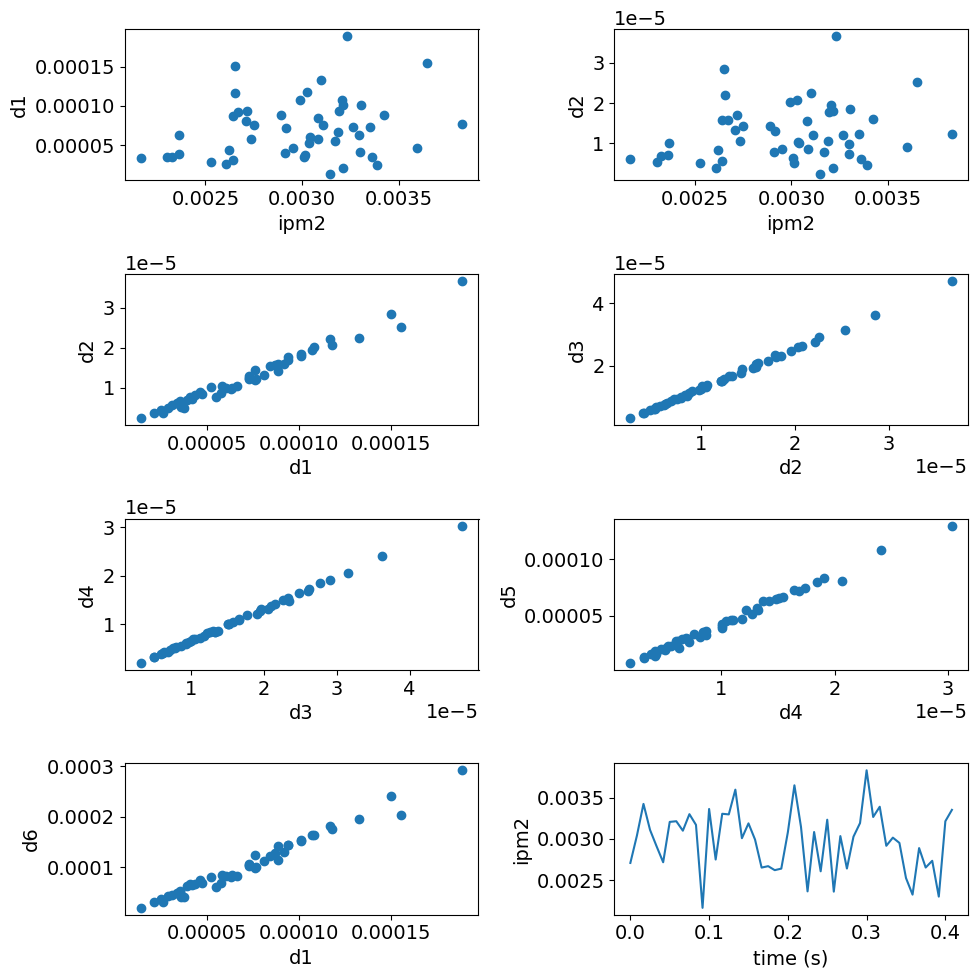

In [19]:
fig, axes = plt.subplots(ncols=2, nrows = 4)

fig.set_figheight(10)
fig.set_figwidth(10)

axes[0,0].scatter(x = ipm2, y = d1)
axes[0,0].set_xlabel("ipm2")
axes[0,0].set_ylabel("d1")

axes[0,1].scatter(x = ipm2, y = d2)
axes[0,1].set_xlabel("ipm2")
axes[0,1].set_ylabel("d2")

axes[1,0].scatter(x = d1, y = d2)
axes[1,0].set_xlabel("d1")
axes[1,0].set_ylabel("d2")

axes[1,1].scatter(x = d2, y = d3)
axes[1,1].set_xlabel("d2")
axes[1,1].set_ylabel("d3")

axes[2,0].scatter(x = d3, y = d4)
axes[2,0].set_xlabel("d3")
axes[2,0].set_ylabel("d4")

axes[2,1].scatter(x = d4, y = d5)
axes[2,1].set_xlabel("d4")
axes[2,1].set_ylabel("d5")

axes[3,0].scatter(x = d1, y = d6)
axes[3,0].set_xlabel("d1")
axes[3,0].set_ylabel("d6")

axes[3,1].plot(np.arange(len(ipm2)).astype(np.float64) / 120,
               ipm2)
axes[3,1].set_xlabel("time (s)")
axes[3,1].set_ylabel("ipm2")


plt.tight_layout()
plt.show()

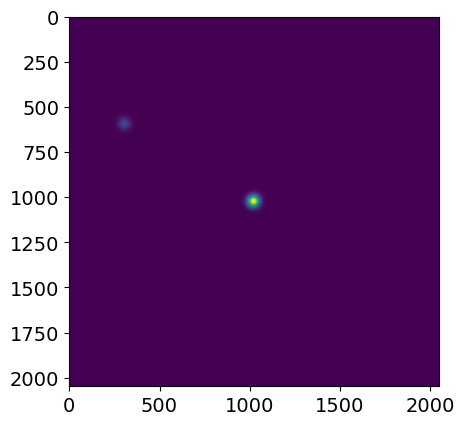

In [9]:
zyla = result_summary[0][0]['zyla']

plt.imshow(np.abs(zyla))
plt.show()